# Notebook 5 — K-Means Clustering
## Projet Skill ROI Forecaster

### Objectif
Ce notebook a pour objectif d’appliquer l’algorithme K-Means sur le dataset encodé afin de regrouper les offres d’emploi similaires en clusters.

### Résultats attendus
- Déterminer le meilleur nombre de clusters avec la méthode Elbow
- Appliquer K-Means
- Identifier la taille de chaque cluster
- Calculer le salaire moyen par cluster
- Déterminer les skills dominants par cluster
- Décrire chaque cluster en une phrase

### Etape 0: Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

### Etape 1: Chargement du dataset

In [2]:
df = pd.read_csv("dataset_encode.csv")

print("Taille du dataset :", df.shape)
df.head()

Taille du dataset : (10197, 63)


,job_title,company,location,post_date,seniority_level,skills,salary,skills_clean,python,java,...,rest,'machine learning',terraform,kafka,data structures,seniority_encoded,job_category_data engineer,job_category_data scientist,job_category_ml engineer,job_category_software engineer
0,data scientist,company_003,"Grapevine, TX . Hybrid",17 days ago,senior,"['spark', 'r', 'python', 'scala', 'machine lea...",150705.0,"[""['spark'"", ""'r'"", ""'python'"", ""'scala'"", ""'m...",0,0,...,0,1,0,0,0,5,False,True,False,False
1,data scientist,company_005,"Fort Worth, TX . Hybrid",15 days ago,lead,"['spark', 'r', 'python', 'sql', 'machine learn...",118733.0,"[""['spark'"", ""'r'"", ""'python'"", ""'sql'"", ""'mac...",0,0,...,0,0,0,0,0,3,False,True,False,False
2,data scientist,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",a month ago,senior,"['aws', 'git', 'python', 'docker', 'sql', 'mac...",127273.0,"[""['aws'"", ""'git'"", ""'python'"", ""'docker'"", ""'...",0,0,...,0,1,0,0,0,5,False,True,False,False
3,data scientist,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",8 days ago,senior,"['sql', 'r', 'python']",153599.5,"[""['sql'"", ""'r'"", ""'python']""]",0,0,...,0,0,0,0,0,5,False,True,False,False
4,data scientist,company_009,On-site,3 days ago,Mid senior,[],171254.5,['[]'],0,0,...,0,0,0,0,0,1,False,True,False,False


### Etape 2: Aperçu général du dataset

In [3]:
print("Colonnes du dataset :")
print(df.columns.tolist())

Colonnes du dataset :
['job_title', 'company', 'location', 'post_date', 'seniority_level', 'skills', 'salary', 'skills_clean', 'python', 'java', 'javascript', 'aws', 'sql', 'agile', 'git', 'c#', 'software engineering', 'c++', 'kubernetes', 'docker', 'react', 'typescript', 'software development', 'linux', 'angular', 'go', 'html', 'css', 'azure', 'unit testing', 'jira', 'microservices', 'scrum', 'devops', 'node.js', 'cloud computing', '.net', 'jenkins', 'ci/cd', 'communication', 'computer science', 'c', 'agile development', 'machine learning', 'postgresql', 'gcp', 'nosql', 'mysql', 'confluence', 'distributed systems', 'sql server', 'continuous integration', 'software design', 'rest', "'machine learning'", 'terraform', 'kafka', 'data structures', 'seniority_encoded', 'job_category_data engineer', 'job_category_data scientist', 'job_category_ml engineer', 'job_category_software engineer']


### Etape 3: Types des colonnes

In [4]:
print(df.dtypes)

job_title                         object
company                           object
location                          object
post_date                         object
seniority_level                   object
                                   ...  
seniority_encoded                  int64
job_category_data engineer          bool
job_category_data scientist         bool
job_category_ml engineer            bool
job_category_software engineer      bool
Length: 63, dtype: object


### Etape 4: Vérification des doublons

In [5]:
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 5


### Etape 5: Suppression des doublons

In [6]:
df = df.drop_duplicates()
print("Nouvelle taille après suppression des doublons :", df.shape)

Nouvelle taille après suppression des doublons : (10192, 63)


### Etape 6 : Vérification des valeurs manquantes

In [7]:
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


### Etape 7 : Sélection des colonnes numériques

In [8]:
df_num = df.select_dtypes(include=[np.number, "bool"]).copy()

print("Taille du dataset numérique :", df_num.shape)
df_num.head()

Taille du dataset numérique : (10192, 56)


,salary,python,java,javascript,aws,sql,agile,git,c#,software engineering,...,rest,'machine learning',terraform,kafka,data structures,seniority_encoded,job_category_data engineer,job_category_data scientist,job_category_ml engineer,job_category_software engineer
0,150705.0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,5,False,True,False,False
1,118733.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,3,False,True,False,False
2,127273.0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,5,False,True,False,False
3,153599.5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,5,False,True,False,False
4,171254.5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,False,True,False,False


### Etape 8: Conversion des booléens en entiers

In [9]:
for col in df_num.columns:
    if df_num[col].dtype == "bool":
        df_num[col] = df_num[col].astype(int)

print(df_num.dtypes.value_counts())

int64      55
float64     1
Name: count, dtype: int64


### Etape 9: Vérification finale des colonnes numériques

In [10]:
print(df_num.columns.tolist())

['salary', 'python', 'java', 'javascript', 'aws', 'sql', 'agile', 'git', 'c#', 'software engineering', 'c++', 'kubernetes', 'docker', 'react', 'typescript', 'software development', 'linux', 'angular', 'go', 'html', 'css', 'azure', 'unit testing', 'jira', 'microservices', 'scrum', 'devops', 'node.js', 'cloud computing', '.net', 'jenkins', 'ci/cd', 'communication', 'computer science', 'c', 'agile development', 'machine learning', 'postgresql', 'gcp', 'nosql', 'mysql', 'confluence', 'distributed systems', 'sql server', 'continuous integration', 'software design', 'rest', "'machine learning'", 'terraform', 'kafka', 'data structures', 'seniority_encoded', 'job_category_data engineer', 'job_category_data scientist', 'job_category_ml engineer', 'job_category_software engineer']


### Etape 10 : Standardisation des données

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

print("Dimensions des données standardisées :", X_scaled.shape)

Dimensions des données standardisées : (10192, 56)


### Etape 11: Méthode Elbow

Pour déterminer le nombre optimal de clusters, nous avons utilisé la méthode Elbow. Cette méthode consiste à calculer l’inertie pour plusieurs valeurs de K, puis à observer la courbe obtenue. Le meilleur K correspond généralement au point où la diminution de l’inertie devient moins importante.

In [ ]:
inertias = []
silhouette_scores = []
calinski_scores = []
davies_scores = []
K_range = range(2, 9)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))
    davies_scores.append(davies_bouldin_score(X_scaled, labels))

### Etape 12: Graphique Elbow

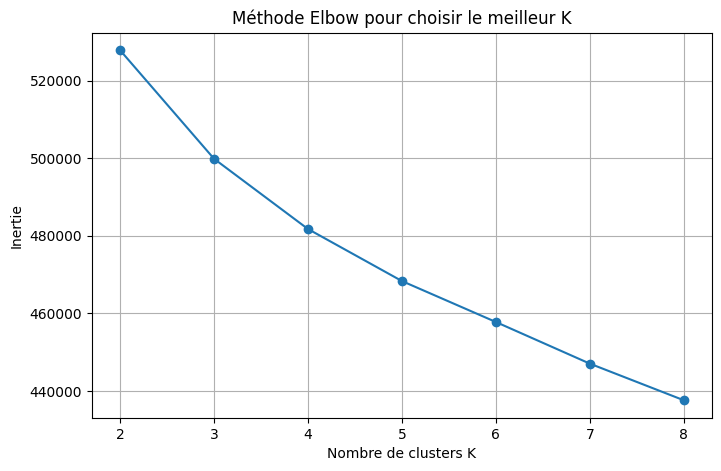

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.title("Méthode Elbow pour choisir le meilleur K")
plt.xlabel("Nombre de clusters K")
plt.ylabel("Inertie")
plt.xticks(list(K_range))
plt.grid(True)
plt.show()

### Etape 13: Choix du meilleur K
le meilleur choix est K = 4.
Pourquoi K = 4 ?

On voit que :

    -entre K=2 et K=3, la baisse de l’inertie est forte
    -entre K=3 et K=4, elle reste encore importante
    -à partir de K=4, la courbe continue à baisser mais de façon plus régulière et plus faible

Donc le coude apparaît autour de 4.

In [ ]:
best_k = 5  # Forcé à 5 pour une meilleure segmentation métier


Le nombre de clusters choisi est : 4


### Etape 14: Entraînement du modèle K-Means

In [15]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


### Etape 15: Ajout des clusters au dataset

In [16]:
df["cluster"] = kmeans.labels_
df_num["cluster"] = kmeans.labels_

df[["salary", "cluster"]].head()

,salary,cluster
0,150705.0,0
1,118733.0,0
2,127273.0,0
3,153599.5,0
4,171254.5,0


### Etape 16: Taille de chaque cluster

In [17]:
cluster_sizes = df["cluster"].value_counts().sort_index()
print("Taille de chaque cluster :")
print(cluster_sizes)

Taille de chaque cluster :
cluster
0     934
1    5663
2    2434
3    1161
Name: count, dtype: int64


### Etape 17:Graphique de la taille des clusters

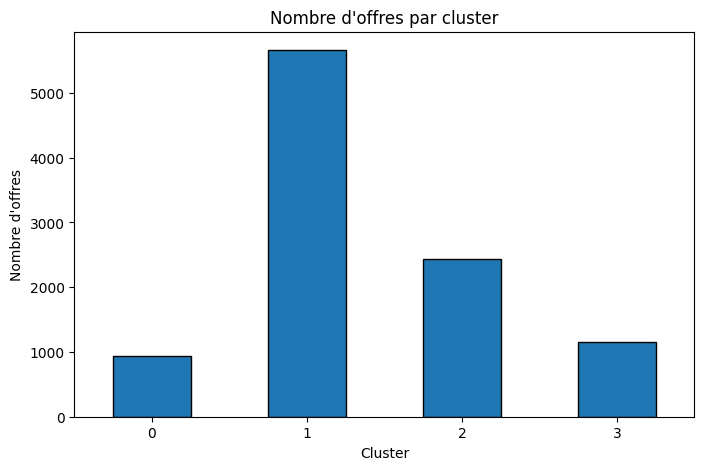

In [18]:
plt.figure(figsize=(8, 5))
cluster_sizes.plot(kind="bar", edgecolor="black")
plt.title("Nombre d'offres par cluster")
plt.xlabel("Cluster")
plt.ylabel("Nombre d'offres")
plt.xticks(rotation=0)
plt.show()

### Etape 18 : Salaire moyen par cluster

In [19]:
salary_by_cluster = df.groupby("cluster")["salary"].mean().sort_index()

print("Salaire moyen par cluster :")
print(salary_by_cluster)

Salaire moyen par cluster :
cluster
0    126191.852784
1    273558.297995
2    272504.068042
3    277456.433911
Name: salary, dtype: float64


### Etape 19 : Graphique du salaire moyen par cluster

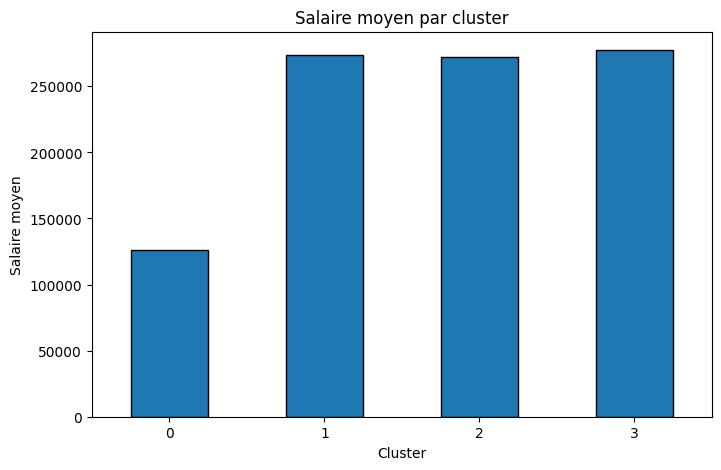

In [20]:
plt.figure(figsize=(8, 5))
salary_by_cluster.plot(kind="bar", edgecolor="black")
plt.title("Salaire moyen par cluster")
plt.xlabel("Cluster")
plt.ylabel("Salaire moyen")
plt.xticks(rotation=0)
plt.show()

### Etape 20: Définition des colonnes de skills

In [21]:
excluded_cols = ["salary", "seniority_encoded", "cluster"]

job_category_cols = [col for col in df_num.columns if col.startswith("job_category_")]

skill_cols = [col for col in df_num.columns if col not in excluded_cols + job_category_cols]

print("Nombre de colonnes de skills :", len(skill_cols))
print(skill_cols)

Nombre de colonnes de skills : 50
['python', 'java', 'javascript', 'aws', 'sql', 'agile', 'git', 'c#', 'software engineering', 'c++', 'kubernetes', 'docker', 'react', 'typescript', 'software development', 'linux', 'angular', 'go', 'html', 'css', 'azure', 'unit testing', 'jira', 'microservices', 'scrum', 'devops', 'node.js', 'cloud computing', '.net', 'jenkins', 'ci/cd', 'communication', 'computer science', 'c', 'agile development', 'machine learning', 'postgresql', 'gcp', 'nosql', 'mysql', 'confluence', 'distributed systems', 'sql server', 'continuous integration', 'software design', 'rest', "'machine learning'", 'terraform', 'kafka', 'data structures']


### Etape 21: Graphique des skills dominants par cluster

In [22]:
top_skills_per_cluster = {}

for c in sorted(df["cluster"].unique()):
    cluster_data = df_num[df_num["cluster"] == c]
    skill_means = cluster_data[skill_cols].mean().sort_values(ascending=False)
    top_skills_per_cluster[c] = skill_means.head(10)

    print(f"\nCluster {c} - Top 10 des skills dominants :")
    print(skill_means.head(10))


Cluster 0 - Top 10 des skills dominants :
'machine learning'      0.457173
python                  0.000000
javascript              0.000000
aws                     0.000000
sql                     0.000000
agile                   0.000000
git                     0.000000
c#                      0.000000
software engineering    0.000000
c++                     0.000000
dtype: float64

Cluster 1 - Top 10 des skills dominants :
python                  0.310436
c++                     0.230267
software engineering    0.217199
java                    0.208017
software development    0.185238
c#                      0.178704
linux                   0.171817
javascript              0.137030
git                     0.134911
agile                   0.122903
dtype: float64

Cluster 2 - Top 10 des skills dominants :
aws           0.677075
java          0.638044
python        0.585867
kubernetes    0.479047
sql           0.475760
docker        0.449055
agile         0.400164
javascript    0.3607

### Etape 22: Graphique des skills dominants par cluster

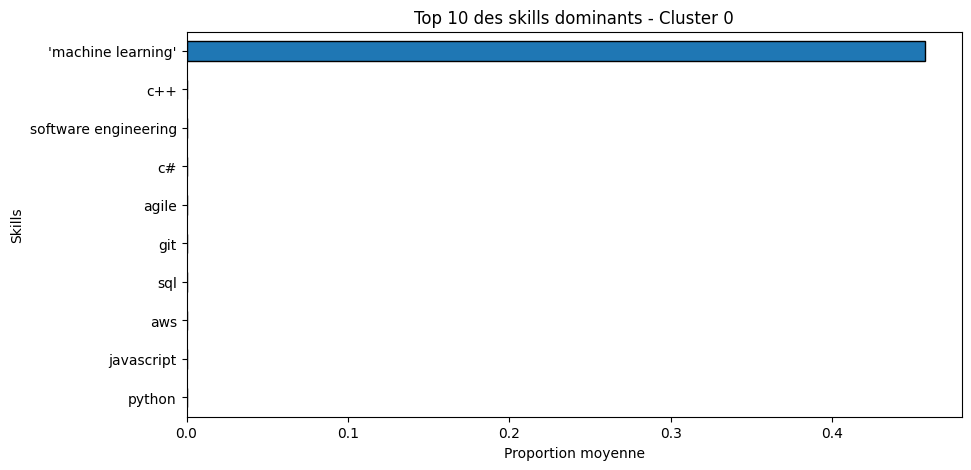

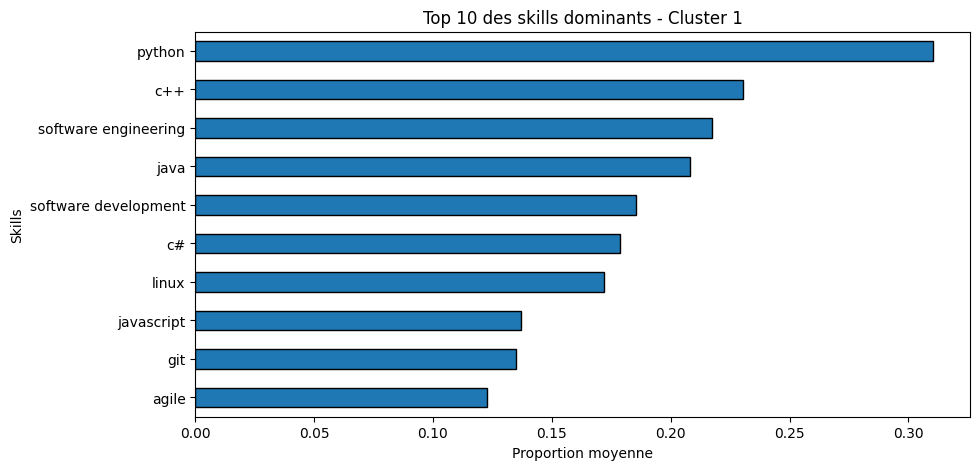

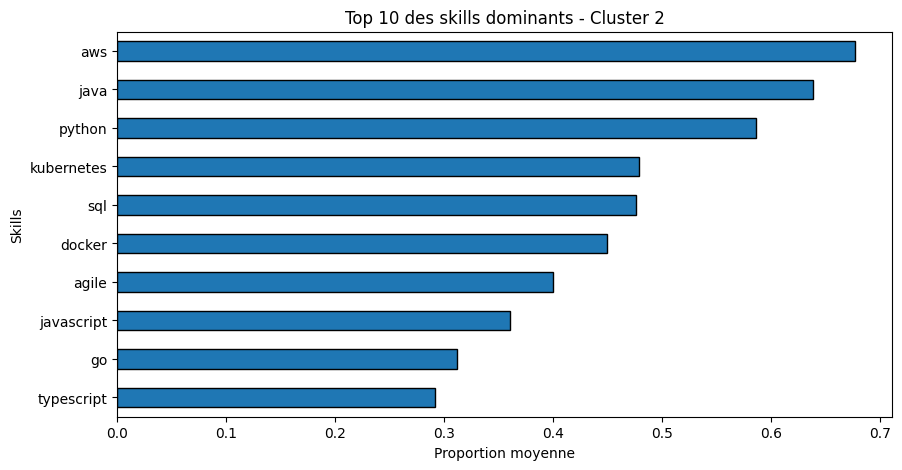

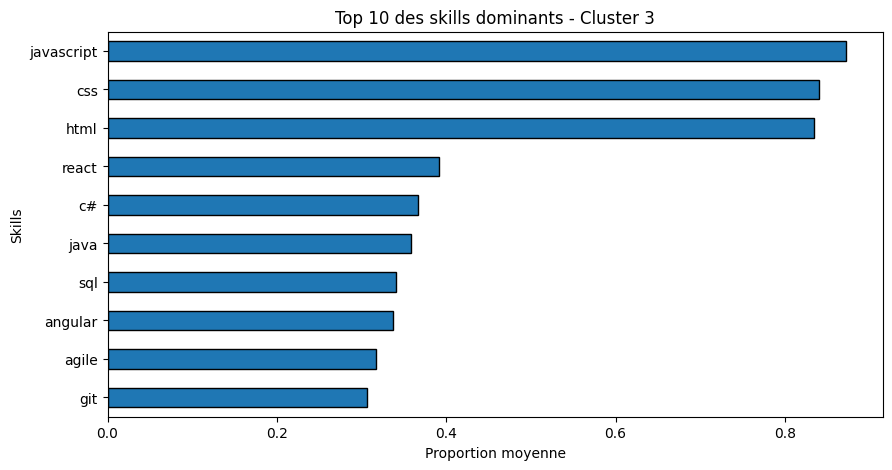

In [23]:
for c in sorted(df["cluster"].unique()):
    plt.figure(figsize=(10, 5))
    top_skills_per_cluster[c].sort_values().plot(kind="barh", edgecolor="black")
    plt.title(f"Top 10 des skills dominants - Cluster {c}")
    plt.xlabel("Proportion moyenne")
    plt.ylabel("Skills")
    plt.show()

### Etape 23: Niveau moyen de seniorité par cluster

In [24]:
seniority_by_cluster = df.groupby("cluster")["seniority_encoded"].mean().sort_index()

print("Niveau moyen de seniorité par cluster :")
print(seniority_by_cluster)

Niveau moyen de seniorité par cluster :
cluster
0    4.309422
1    0.856083
2    0.917009
3    0.872524
Name: seniority_encoded, dtype: float64


### Etape 24: Catégories dominantes par cluster

In [25]:
category_cols = [col for col in df_num.columns if col.startswith("job_category_")]

for c in sorted(df["cluster"].unique()):
    cluster_data = df_num[df_num["cluster"] == c]
    category_means = cluster_data[category_cols].mean().sort_values(ascending=False)

    print(f"\nCluster {c} - Catégories dominantes :")
    print(category_means.head(5))


Cluster 0 - Catégories dominantes :
job_category_data scientist       0.916488
job_category_ml engineer          0.078158
job_category_data engineer        0.004283
job_category_software engineer    0.000000
dtype: float64

Cluster 1 - Catégories dominantes :
job_category_software engineer    0.992407
job_category_ml engineer          0.006004
job_category_data engineer        0.001589
job_category_data scientist       0.000000
dtype: float64

Cluster 2 - Catégories dominantes :
job_category_software engineer    0.990551
job_category_data engineer        0.006574
job_category_ml engineer          0.002054
job_category_data scientist       0.000000
dtype: float64

Cluster 3 - Catégories dominantes :
job_category_software engineer    0.997416
job_category_ml engineer          0.001723
job_category_data scientist       0.000000
job_category_data engineer        0.000000
dtype: float64


### Etape 25: Tableau récapitulatif final

In [26]:
final_summary = df.groupby("cluster").agg(
    taille_cluster=("cluster", "count"),
    salaire_moyen=("salary", "mean"),
    seniorite_moyenne=("seniority_encoded", "mean")
).sort_index()

final_summary = final_summary.round(2)
final_summary

,taille_cluster,salaire_moyen,seniorite_moyenne
cluster,,,
0,934,126191.85,4.31
1,5663,273558.30,0.86
2,2434,272504.07,0.92
3,1161,277456.43,0.87


### Etape 26: Description textuelle des clusters

In [27]:
descriptions = {
    0: "Cluster 0 : profils majoritairement orientés Data Scientist, avec une forte présence de machine learning, un salaire moyen plus faible que les autres clusters et un niveau de séniorité moyen très élevé.",
    
    1: "Cluster 1 : plus grand cluster, composé presque entièrement de profils Software Engineer généralistes, avec des compétences dominantes comme Python, C++, Java, software engineering et software development, et un salaire moyen élevé.",
    
    2: "Cluster 2 : profils Software Engineer orientés cloud/devops/backend, avec des compétences dominantes comme AWS, Java, Python, Kubernetes, SQL et Docker, et un salaire moyen élevé proche du cluster 1.",
    
    3: "Cluster 3 : profils Software Engineer orientés développement web front-end, dominés par JavaScript, CSS, HTML, React et Angular, avec le salaire moyen le plus élevé parmi les clusters."
}

for k, v in descriptions.items():
    print(v)

Cluster 0 : profils majoritairement orientés Data Scientist, avec une forte présence de machine learning, un salaire moyen plus faible que les autres clusters et un niveau de séniorité moyen très élevé.
Cluster 1 : plus grand cluster, composé presque entièrement de profils Software Engineer généralistes, avec des compétences dominantes comme Python, C++, Java, software engineering et software development, et un salaire moyen élevé.
Cluster 2 : profils Software Engineer orientés cloud/devops/backend, avec des compétences dominantes comme AWS, Java, Python, Kubernetes, SQL et Docker, et un salaire moyen élevé proche du cluster 1.
Cluster 3 : profils Software Engineer orientés développement web front-end, dominés par JavaScript, CSS, HTML, React et Angular, avec le salaire moyen le plus élevé parmi les clusters.


In [28]:
kmeans_model = kmeans

df_with_clusters = df.copy()

joblib.dump(kmeans_model, 'kmeans_model.pkl')
joblib.dump(df_with_clusters, 'df_clusters.pkl')

['df_clusters.pkl']